# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 9 — Frequency & Bearish-Exit Extensions

This extension leaves Blocks 1–8 unchanged and tests two pre-specified questions:

1. Does a **daily** Pine-derived state engine add value relative to the canonical **weekly** state engine?
2. Does a bearish signal work better as:
   - **UNDERWEIGHT** — canonical 50% underweight,
   - **EXIT_REDISTRIBUTE** — zero the bearish sector and redistribute across remaining sectors,
   - **EXIT_CASH** — zero the bearish sector and hold the released capital in cash?

The six architectures are compared on CAGR, volatility, Sharpe, Sortino, maximum drawdown, Calmar, turnover, transaction-cost sensitivity, and terminal wealth.

The daily staircase uses **0.02 per trading day**, approximately preserving the canonical weekly adjustment speed of **0.10 per week**. Cash is assumed to earn **0%** in this extension so the test isolates the exit mechanism itself.


In [1]:
# ============================================================
# BLOCK 9.1 — ENVIRONMENT, DRIVE & MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/"
    "State-Dependent U.S. Equity Sector Rotation - "
    "A Systematic Framework for Trend-Based Active Sector Allocation"
)

DIRS = {
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

def load_manifest(filename):
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block1 = load_manifest("block_1_research_configuration.json")
block2 = load_manifest("block_2_universe_data_weights.json")
block3 = load_manifest("block_3_signal_engine.json")
block4 = load_manifest("block_4_state_active_weights.json")
block5 = load_manifest("block_5_portfolio_engine.json")
block6 = load_manifest("block_6_performance_analytics.json")
block7 = load_manifest("block_7_visual_diagnostics.json")
block8 = load_manifest("block_8_robustness_costs_sensitivity.json")

SECTOR_RECORDS = block1["sector_universe"]
SECTOR_TICKERS = [x["ticker"] for x in SECTOR_RECORDS]
assert len(SECTOR_TICKERS) == 11

print("Loaded and validated Blocks 1–8.")


Mounted at /content/drive
Loaded and validated Blocks 1–8.


In [2]:
# ============================================================
# BLOCK 9.2 — IMPORTS & SOURCE DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

def resolve_path(mapping, keys, label):
    for key in keys:
        if key in mapping:
            p = Path(mapping[key])
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not resolve {label}; tried {keys}")

DAILY_CLOSE_PATH = resolve_path(
    block2["saved_files"],
    ["daily_adjusted_close"],
    "daily adjusted close",
)
STRATEGIC_WEIGHT_PATH = resolve_path(
    block2["saved_files"],
    ["strategic_weights", "weekly_strategic_weights"],
    "strategic weights",
)
WEEKLY_STATE_PATH = resolve_path(
    block4["saved_files"],
    [
        "canonical_active_weights_long",
        "active_weights_long",
        "weekly_state_dependent_active_weights_long",
    ],
    "weekly state/active-weight file",
)
WEEKLY_SECTOR_RETURN_PATH = resolve_path(
    block5["saved_files"],
    ["sector_holding_returns", "weekly_execution_holding_returns_sectors"],
    "weekly sector holding returns",
)

daily_close = pd.read_parquet(DAILY_CLOSE_PATH)
strategic_weekly = pd.read_parquet(STRATEGIC_WEIGHT_PATH)
weekly_state_long = pd.read_parquet(WEEKLY_STATE_PATH)
weekly_sector_returns = pd.read_parquet(WEEKLY_SECTOR_RETURN_PATH)

for obj in [daily_close, strategic_weekly, weekly_sector_returns]:
    obj.index = pd.to_datetime(obj.index)
    obj.sort_index(inplace=True)

weekly_state_long["date"] = pd.to_datetime(weekly_state_long["date"])
weekly_state_long.sort_values(["ticker", "date"], inplace=True)

SECTOR_COLS = [c for c in daily_close.columns if c in SECTOR_TICKERS]
assert set(SECTOR_COLS) == set(SECTOR_TICKERS)

print("Daily price sample:", daily_close.index.min().date(), "to", daily_close.index.max().date())
print("Weekly state columns:", list(weekly_state_long.columns))


Daily price sample: 2018-06-19 to 2026-08-28
Weekly state columns: ['date', 'ticker', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'raw_spread_std', 'spread_std', 'upper_bb', 'lower_bb', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_flat', 'signal_flat', 'osc_turns_red', 'cross_below_zero', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'indicator_ready', 'tsmom_12m_return', 'tsmom_sign', 'signal_observation_date', 'execution_date', 'execution_weekday', 'pine_zone_mode', 'pine_zone_state', 'early_reversal_exit_mode', 'early_reversal_saw_below_bb', 'pullback_saw_above_bb', 'position_held', 'strategic_state', 'tactical_state', 'early_reversal_entry_intersection', 'pullback_entry_intersection', 'start_early_reversal', 'end_early_reversal', 'start_pullback', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_e

In [3]:
# ============================================================
# BLOCK 9.3 — CONSTANTS & HELPERS
# ============================================================

SMOOTHING_LENGTH = 5
FAST_EMA = 20
SLOW_EMA = 50
SIGNAL_EMA = 25
BB_LOOKBACK = 20
BB_SMOOTHING = 5
DIRECTION_LOOKBACK = 2

ACTIVE_BOUND = 0.50
WEEKLY_STEP = 0.10
DAILY_STEP = 0.02
COST_SCENARIOS_BPS = [0, 5, 10, 20]

def supersmoother(series, length):
    vals = series.astype(float).values
    out = np.full(len(vals), np.nan)

    a1 = np.exp(-1.414 * np.pi / length)
    b1 = 2.0 * a1 * np.cos(1.414 * np.pi / length)
    c2 = b1
    c3 = -a1 * a1
    c1 = 1.0 - c2 - c3

    for i, x0 in enumerate(vals):
        if np.isnan(x0):
            continue
        x1 = vals[i-1] if i >= 1 and not np.isnan(vals[i-1]) else 0.0
        p1 = out[i-1] if i >= 1 and not np.isnan(out[i-1]) else 0.0
        p2 = out[i-2] if i >= 2 and not np.isnan(out[i-2]) else 0.0
        out[i] = c1 * (x0 + x1) / 2 + c2 * p1 + c3 * p2

    return pd.Series(out, index=series.index)

def indicator_frame(close):
    smooth = supersmoother(close, SMOOTHING_LENGTH)
    fast = smooth.ewm(span=FAST_EMA, adjust=False, min_periods=1).mean()
    slow = smooth.ewm(span=SLOW_EMA, adjust=False, min_periods=1).mean()
    osc = fast - slow
    sig = osc.ewm(span=SIGNAL_EMA, adjust=False, min_periods=1).mean()
    spread = osc - sig
    raw_std = spread.rolling(BB_LOOKBACK, min_periods=BB_LOOKBACK).std(ddof=0)
    width = raw_std.ewm(span=BB_SMOOTHING, adjust=False, min_periods=1).mean()
    upper = sig + width
    lower = sig - width
    slope = osc - osc.shift(DIRECTION_LOOKBACK)

    x = pd.DataFrame({
        "oscillator": osc,
        "signalLine": sig,
        "upperBB": upper,
        "lowerBB": lower,
        "oscSlope": slope,
    })
    x["oscRising"] = x["oscSlope"] > 0
    x["oscFalling"] = x["oscSlope"] < 0
    prev_fall = x["oscFalling"].shift(1).fillna(False).astype(bool)
    x["oscTurnsRed"] = x["oscFalling"] & (~prev_fall)
    x["crossBelowZero"] = (osc < 0) & (osc.shift(1) >= 0)
    x["signalCrossAboveZero"] = (sig > 0) & (sig.shift(1) <= 0)
    x["oscCrossAboveSignal"] = (osc > sig) & (osc.shift(1) <= sig.shift(1))
    return x

def normalize_rows(df):
    total = df.sum(axis=1)
    return df.div(total.replace(0, np.nan), axis=0)

def cagr(r, ppy):
    if len(r) == 0:
        return np.nan
    terminal = float((1 + r).prod())
    years = len(r) / ppy
    return terminal ** (1 / years) - 1 if terminal > 0 and years > 0 else np.nan

def ann_vol(r, ppy):
    return float(r.std(ddof=1) * np.sqrt(ppy))

def sharpe(r, ppy):
    sd = r.std(ddof=1)
    return np.nan if sd == 0 or pd.isna(sd) else float(r.mean() / sd * np.sqrt(ppy))

def sortino(r, ppy):
    d = r[r < 0]
    if len(d) == 0:
        return np.nan
    ddev = np.sqrt((d**2).mean())
    return np.nan if ddev == 0 else float(r.mean() / ddev * np.sqrt(ppy))

def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return float((wealth / wealth.cummax() - 1).min())

def calmar(r, ppy):
    g = cagr(r, ppy)
    mdd = max_drawdown(r)
    return np.nan if mdd == 0 or pd.isna(mdd) else float(g / abs(mdd))

def summarize(r, ppy):
    return {
        "CAGR": cagr(r, ppy),
        "Annualized Volatility": ann_vol(r, ppy),
        "Sharpe": sharpe(r, ppy),
        "Sortino": sortino(r, ppy),
        "Max Drawdown": max_drawdown(r),
        "Calmar": calmar(r, ppy),
        "Terminal Wealth": float((1 + r).prod()),
    }


In [4]:
# ============================================================
# BLOCK 9.4 — EXACT DAILY STATE ENGINE
# ============================================================

def build_state(close):
    x = indicator_frame(close)

    zone = 0
    early_exit_mode = 0
    early_saw_below = False
    pullback_saw_above = False
    held = False
    recs = []

    for dt, row in x.iterrows():
        osc, sig = row["oscillator"], row["signalLine"]
        lower, upper = row["lowerBB"], row["upperBB"]

        if pd.isna(osc) or pd.isna(sig) or pd.isna(lower) or pd.isna(upper):
            recs.append((dt, 0, False, "BEARISH", "NONE"))
            continue

        accumulation = zone in (1, 2)
        can_search = not accumulation

        if can_search:
            if osc < 0 and osc < lower:
                early_saw_below = True
            if osc >= 0:
                early_saw_below = False
            if osc > 0 and osc > upper:
                pullback_saw_above = True
            if osc <= 0:
                pullback_saw_above = False
        else:
            early_saw_below = False
            pullback_saw_above = False

        early_entry = (
            can_search and early_saw_below and osc < 0
            and osc > lower and bool(row["oscRising"])
        )
        pullback_entry = (
            can_search and pullback_saw_above and osc > 0
            and osc < upper and bool(row["oscFalling"])
        )
        profit_entry = (
            can_search and not early_entry and not pullback_entry
            and osc > 0 and bool(row["oscTurnsRed"])
        )

        start_early = False
        end_early = False

        if early_entry:
            zone = 1
            early_exit_mode = 1 if sig < 0 else 2
            start_early = True

        elif pullback_entry:
            zone = 2

        elif profit_entry:
            zone = 3

        else:
            if zone == 1:
                if early_exit_mode == 1 and bool(row["signalCrossAboveZero"]):
                    zone = 0
                    early_exit_mode = 0
                    end_early = True
                elif early_exit_mode == 2 and bool(row["oscCrossAboveSignal"]):
                    zone = 0
                    early_exit_mode = 0
                    end_early = True
            elif zone == 2:
                if bool(row["oscRising"]) or osc < 0:
                    zone = 0
            elif zone == 3:
                if bool(row["crossBelowZero"]):
                    zone = 0

        if held and bool(row["crossBelowZero"]):
            held = False
        elif (not held) and start_early:
            held = True

        if not held:
            strategic_state = "BEARISH"
        elif zone == 1:
            strategic_state = "EARLY_REVERSAL"
        elif end_early:
            strategic_state = "CONFIRMED_TREND"
        else:
            strategic_state = "NORMAL_POSITIVE_TREND"

        if not held:
            tactical_state = "NONE"
        elif zone == 2:
            tactical_state = "PULLBACK_ACCUMULATION"
        elif zone == 3:
            tactical_state = "PROFIT_TAKING"
        else:
            tactical_state = "NONE"

        recs.append((dt, int(zone), bool(held), strategic_state, tactical_state))

    return pd.DataFrame(
        recs,
        columns=["date", "pine_zone_state", "positionHeld", "strategic_state", "tactical_state"],
    )

daily_state_long = pd.concat(
    [
        build_state(daily_close[t]).assign(ticker=t)
        for t in SECTOR_COLS
    ],
    ignore_index=True,
)

print("Daily state rows:", len(daily_state_long))


/tmp/ipykernel_4098/2255714276.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_fall = x["oscFalling"].shift(1).fillna(False).astype(bool)
/tmp/ipykernel_4098/2255714276.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_fall = x["oscFalling"].shift(1).fillna(False).astype(bool)
/tmp/ipykernel_4098/2255714276.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('

Daily state rows: 22660


/tmp/ipykernel_4098/2255714276.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_fall = x["oscFalling"].shift(1).fillna(False).astype(bool)


In [5]:
# ============================================================
# BLOCK 9.5 — ACTIVE MULTIPLIERS
# ============================================================

def rebuild_active(state_df, step, bound=0.50):
    """
    Rebuild the active-multiplier path from saved strategic/tactical states.

    Block 4's saved weekly long table does not necessarily persist a
    `positionHeld` column. This is not a loss of information because the
    Block 4 research state definition is:
        BEARISH  <=> positionHeld == False
        otherwise positionHeld == True

    The daily engine does persist `positionHeld`, so this function supports
    both schemas explicitly.
    """
    required = {"date", "ticker", "strategic_state", "tactical_state"}
    missing = required.difference(state_df.columns)
    if missing:
        raise ValueError(
            "State table is missing required columns: "
            f"{sorted(missing)}\nAvailable columns: {list(state_df.columns)}"
        )

    if "positionHeld" in state_df.columns:
        held_source = "positionHeld"
    elif "position_held" in state_df.columns:
        held_source = "position_held"
    else:
        held_source = None

    rows = []

    for ticker, g in state_df.groupby("ticker", sort=False):
        a_prev = 0.0

        for row in g.sort_values("date").itertuples(index=False):
            strategic_state = row.strategic_state
            tactical_state = row.tactical_state

            if strategic_state == "BEARISH":
                a = -bound
            elif strategic_state == "CONFIRMED_TREND":
                a = 0.0
            elif strategic_state == "EARLY_REVERSAL":
                a = min(0.0, a_prev + step)
            elif tactical_state == "PULLBACK_ACCUMULATION":
                a = min(bound, a_prev + step)
            elif tactical_state == "PROFIT_TAKING":
                a = max(0.0, a_prev - step)
            elif strategic_state == "NORMAL_POSITIVE_TREND":
                a = min(bound, max(0.0, a_prev))
            else:
                a = a_prev

            a = float(np.round(a, 10))

            # Exact reconstruction of strategic position state.
            if held_source == "positionHeld":
                held = bool(getattr(row, "positionHeld"))
            elif held_source == "position_held":
                held = bool(getattr(row, "position_held"))
            else:
                held = strategic_state != "BEARISH"

            rows.append({
                "date": row.date,
                "ticker": ticker,
                "active_multiplier": a,
                "positionHeld": held,
            })

            a_prev = a

    return pd.DataFrame(rows)


print("Weekly state columns:")
print(list(weekly_state_long.columns))
print("\nDaily state columns:")
print(list(daily_state_long.columns))

weekly_active_long = rebuild_active(
    weekly_state_long,
    WEEKLY_STEP,
    ACTIVE_BOUND,
)

daily_active_long = rebuild_active(
    daily_state_long,
    DAILY_STEP,
    ACTIVE_BOUND,
)


def pivot(df, col):
    return (
        df.pivot(index="date", columns="ticker", values=col)
        .sort_index()
    )


weekly_active = pivot(
    weekly_active_long,
    "active_multiplier",
)

weekly_held = pivot(
    weekly_active_long.assign(
        positionHeld=weekly_active_long["positionHeld"].astype(float)
    ),
    "positionHeld",
)

daily_active = pivot(
    daily_active_long,
    "active_multiplier",
)

daily_held = pivot(
    daily_active_long.assign(
        positionHeld=daily_active_long["positionHeld"].astype(float)
    ),
    "positionHeld",
)

# Sanity checks.
assert weekly_held.isin([0.0, 1.0]).all().all()
assert daily_held.isin([0.0, 1.0]).all().all()

print("\nActive multiplier paths built successfully.")

if "positionHeld" in weekly_state_long.columns:
    weekly_held_source = "saved positionHeld column"
elif "position_held" in weekly_state_long.columns:
    weekly_held_source = "saved position_held column"
else:
    weekly_held_source = "reconstructed from strategic_state != 'BEARISH'"

print("Weekly positionHeld source:", weekly_held_source)


Weekly state columns:
['date', 'ticker', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'raw_spread_std', 'spread_std', 'upper_bb', 'lower_bb', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_flat', 'signal_flat', 'osc_turns_red', 'cross_below_zero', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'indicator_ready', 'tsmom_12m_return', 'tsmom_sign', 'signal_observation_date', 'execution_date', 'execution_weekday', 'pine_zone_mode', 'pine_zone_state', 'early_reversal_exit_mode', 'early_reversal_saw_below_bb', 'pullback_saw_above_bb', 'position_held', 'strategic_state', 'tactical_state', 'early_reversal_entry_intersection', 'pullback_entry_intersection', 'start_early_reversal', 'end_early_reversal', 'start_pullback', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'previous

In [6]:
# ============================================================
# BLOCK 9.6 — DAILY STRATEGIC BASE & PORTFOLIO VARIANTS
# ============================================================

strategic_daily = strategic_weekly.reindex(daily_close.index).ffill()[SECTOR_COLS]
strategic_daily = strategic_daily.dropna()

def construct(base, active, held, mode):
    idx = base.index.intersection(active.index)
    cols = [c for c in SECTOR_COLS if c in base.columns and c in active.columns]
    b = base.reindex(idx)[cols]
    a = active.reindex(idx)[cols]
    h = held.reindex(idx)[cols]

    if mode == "UNDERWEIGHT":
        w = normalize_rows(b * (1 + a))
        cash = pd.Series(0.0, index=idx)
    elif mode == "EXIT_REDISTRIBUTE":
        w = normalize_rows(b.where(h > 0.5, 0.0)).fillna(0.0)
        cash = pd.Series(0.0, index=idx)
    elif mode == "EXIT_CASH":
        w = b.where(h > 0.5, 0.0)
        cash = (1.0 - w.sum(axis=1)).clip(0, 1)
    else:
        raise ValueError(mode)

    return w, cash

MODES = ["UNDERWEIGHT", "EXIT_REDISTRIBUTE", "EXIT_CASH"]

weekly_modes = {
    m: construct(strategic_weekly[SECTOR_COLS], weekly_active, weekly_held, m)
    for m in MODES
}
daily_modes = {
    m: construct(strategic_daily, daily_active, daily_held, m)
    for m in MODES
}

print("Built six extension architectures.")


Built six extension architectures.


In [7]:
# ============================================================
# BLOCK 9.7 — RETURN & TURNOVER ENGINES
# ============================================================

# Weekly uses Block 5's exact execution-to-execution sector return matrix.
weekly_returns = {}
weekly_turnover = {}

for mode, (w, cash) in weekly_modes.items():
    common = weekly_sector_returns.index.intersection(w.index)
    ww = w.reindex(common)[SECTOR_COLS]
    rr = weekly_sector_returns.reindex(common)[SECTOR_COLS]
    pr = (ww * rr).sum(axis=1)  # cash return = 0%
    weekly_returns[mode] = pr.dropna()
    weekly_turnover[mode] = 0.5 * ww.diff().abs().sum(axis=1).fillna(0.0)

# Daily state at close t governs next close-to-close return.
daily_forward_returns = daily_close[SECTOR_COLS].pct_change().shift(-1)

daily_returns = {}
daily_turnover = {}

for mode, (w, cash) in daily_modes.items():
    common = daily_forward_returns.index.intersection(w.index)
    ww = w.reindex(common)[SECTOR_COLS]
    rr = daily_forward_returns.reindex(common)[SECTOR_COLS]
    pr = (ww * rr).sum(axis=1).dropna()
    daily_returns[mode] = pr
    daily_turnover[mode] = (
        0.5 * ww.diff().abs().sum(axis=1).fillna(0.0).reindex(pr.index)
    )

# Fair comparison window.
COMMON_START = max(
    max(x.index.min() for x in weekly_returns.values()),
    max(x.index.min() for x in daily_returns.values()),
)
COMMON_END = min(
    min(x.index.max() for x in weekly_returns.values()),
    min(x.index.max() for x in daily_returns.values()),
)

for m in MODES:
    weekly_returns[m] = weekly_returns[m].loc[COMMON_START:COMMON_END]
    weekly_turnover[m] = weekly_turnover[m].loc[COMMON_START:COMMON_END]
    daily_returns[m] = daily_returns[m].loc[COMMON_START:COMMON_END]
    daily_turnover[m] = daily_turnover[m].loc[COMMON_START:COMMON_END]

print("Common comparison window:", COMMON_START.date(), "to", COMMON_END.date())


Common comparison window: 2019-06-21 to 2026-08-14


In [8]:
# ============================================================
# BLOCK 9.8 — CORE PERFORMANCE
# ============================================================

rows = []

for mode in MODES:
    r = weekly_returns[mode]
    rows.append({
        "Frequency": "WEEKLY",
        "Bearish_Treatment": mode,
        **summarize(r, 52),
        "Mean Weekly/Daily Turnover": weekly_turnover[mode].mean(),
        "Annualized Turnover Approx": weekly_turnover[mode].mean() * 52,
        "Mean Cash Weight": weekly_modes[mode][1].reindex(r.index).fillna(0).mean(),
    })

for mode in MODES:
    r = daily_returns[mode]
    rows.append({
        "Frequency": "DAILY",
        "Bearish_Treatment": mode,
        **summarize(r, 252),
        "Mean Weekly/Daily Turnover": daily_turnover[mode].mean(),
        "Annualized Turnover Approx": daily_turnover[mode].mean() * 252,
        "Mean Cash Weight": daily_modes[mode][1].reindex(r.index).fillna(0).mean(),
    })

core_summary = pd.DataFrame(rows).set_index(["Frequency", "Bearish_Treatment"])
display(core_summary)


CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  Mean Weekly/Daily Turnover  Annualized Turnover Approx  Mean Cash Weight
Frequency Bearish_Treatment                                                                                                                                                                        
WEEKLY    UNDERWEIGHT        0.139616               0.173575  0.840655  0.741352     -0.351040  0.397722         2.559913                    0.011802                    0.613680          0.000000
          EXIT_REDISTRIBUTE  0.155878               0.147510  1.057434  0.908056     -0.172295  0.904716         2.834537                    0.020974                    1.090629          0.000000
          EXIT_CASH          0.075125               0.070102  1.069123  0.910059     -0.091613  0.820017         1.683687                    0.005635                    0.293016          0.529724
DAILY     UNDERWEIGHT        0.122447               0.178196  0.737937  0.688239     -0.349771  0.350079         2.278933                    0.009633                    2.427403          0.000000
          EXIT_REDISTRIBUTE  0.133890               0.149347  0.916397  0.851244     -0.190587  0.702513         2.449866                    0.025169                    6.342554          0.000000
          EXIT_CASH          0.091919               0.095876  0.965378  0.895600     -0.123834  0.742279         1.872128                    0.007203                    1.815276          0.362052

In [9]:
# ============================================================
# BLOCK 9.9 — COST SENSITIVITY
# ============================================================

rows = []

for bps in COST_SCENARIOS_BPS:
    for mode in MODES:
        gross = weekly_returns[mode]
        net = gross - weekly_turnover[mode].reindex(gross.index).fillna(0) * bps / 10000
        rows.append({
            "Cost_bps": bps,
            "Frequency": "WEEKLY",
            "Bearish_Treatment": mode,
            **summarize(net, 52),
        })

        gross = daily_returns[mode]
        net = gross - daily_turnover[mode].reindex(gross.index).fillna(0) * bps / 10000
        rows.append({
            "Cost_bps": bps,
            "Frequency": "DAILY",
            "Bearish_Treatment": mode,
            **summarize(net, 252),
        })

cost_summary = pd.DataFrame(rows).set_index(
    ["Cost_bps", "Frequency", "Bearish_Treatment"]
)
display(cost_summary)


CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth
Cost_bps Frequency Bearish_Treatment                                                                                              
0        WEEKLY    UNDERWEIGHT        0.139616               0.173575  0.840655  0.741352     -0.351040  0.397722         2.559913
         DAILY     UNDERWEIGHT        0.122447               0.178196  0.737937  0.688239     -0.349771  0.350079         2.278933
         WEEKLY    EXIT_REDISTRIBUTE  0.155878               0.147510  1.057434  0.908056     -0.172295  0.904716         2.834537
         DAILY     EXIT_REDISTRIBUTE  0.133890               0.149347  0.916397  0.851244     -0.190587  0.702513         2.449866
         WEEKLY    EXIT_CASH          0.075125               0.070102  1.069123  0.910059     -0.091613  0.820017         1.683687
         DAILY     EXIT_CASH          0.091919               0.095876  0.965378  0.895600     -0.123834  0.742279         1.872128
5        WEEKLY    UNDERWEIGHT        0.139268               0.173573  0.838896  0.739687     -0.351073  0.396691         2.554287
         DAILY     UNDERWEIGHT        0.121086               0.178201  0.731109  0.682097     -0.349959  0.346000         2.259289
         WEEKLY    EXIT_REDISTRIBUTE  0.155246               0.147529  1.053599  0.904272     -0.172698  0.898943         2.823403
         DAILY     EXIT_REDISTRIBUTE  0.130305               0.149323  0.895304  0.832319     -0.193339  0.673974         2.395168
         WEEKLY    EXIT_CASH          0.074967               0.070100  1.067066  0.908153     -0.091646  0.818014         1.681918
         DAILY     EXIT_CASH          0.090929               0.095873  0.955940  0.887088     -0.124116  0.732615         1.860057
10       WEEKLY    UNDERWEIGHT        0.138919               0.173572  0.837136  0.738024     -0.351107  0.395660         2.548673
         DAILY     UNDERWEIGHT        0.119725               0.178205  0.724280  0.675531     -0.350147  0.341929         2.239814
         WEEKLY    EXIT_REDISTRIBUTE  0.154614               0.147549  1.049761  0.900489     -0.173101  0.893200         2.812312
         DAILY     EXIT_REDISTRIBUTE  0.126731               0.149302  0.874190  0.811783     -0.196081  0.646321         2.341684
         WEEKLY    EXIT_CASH          0.074810               0.070098  1.065009  0.906247     -0.091678  0.816013         1.680150
         DAILY     EXIT_CASH          0.089940               0.095870  0.946499  0.879130     -0.124398  0.723003         1.848065
20       WEEKLY    UNDERWEIGHT        0.138222               0.173568  0.833618  0.734697     -0.351174  0.393601         2.537482
         DAILY     UNDERWEIGHT        0.117010               0.178214  0.710623  0.662821     -0.350523  0.333815         2.201365
         WEEKLY    EXIT_REDISTRIBUTE  0.153350               0.147591  1.042078  0.896550     -0.173906  0.881800         2.790255
         DAILY     EXIT_REDISTRIBUTE  0.119616               0.149267  0.831903  0.771290     -0.201539  0.593513         2.238253
         WEEKLY    EXIT_CASH          0.074496               0.070093  1.060893  0.906097     -0.091742  0.812016         1.676622
         DAILY     EXIT_CASH          0.087965               0.095865  0.927609  0.860953     -0.124962  0.703932         1.824310

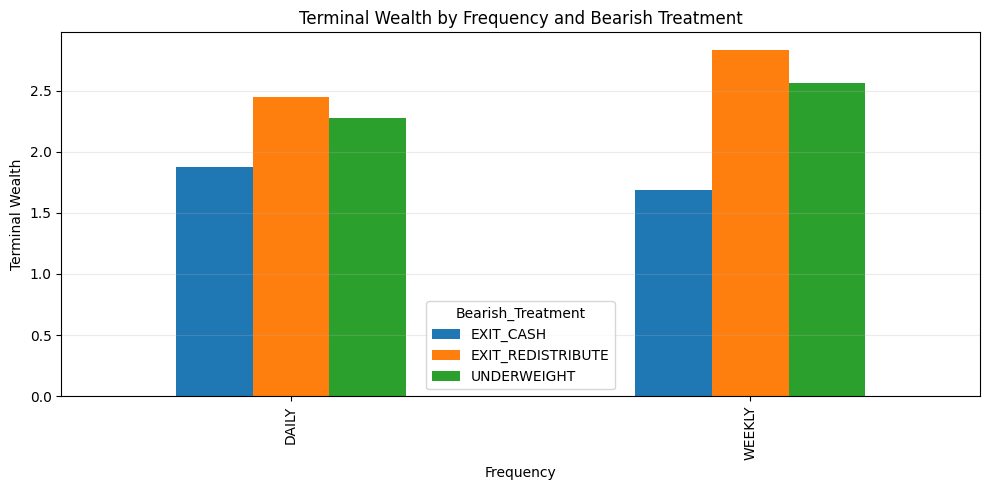

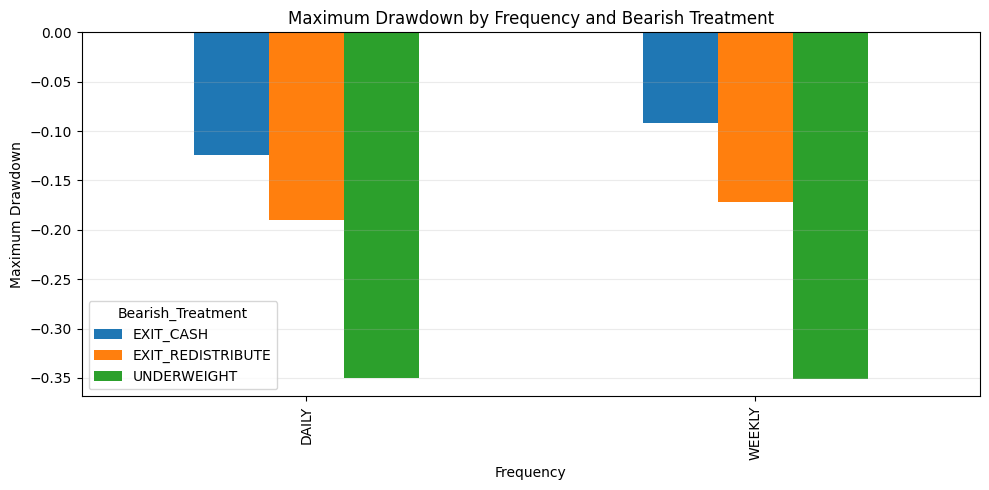

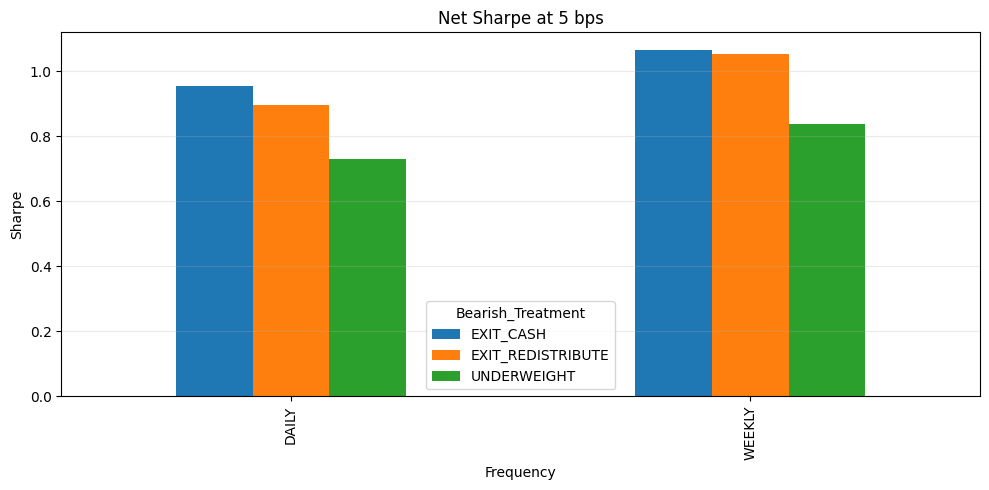

In [10]:
# ============================================================
# BLOCK 9.10 — FIGURES
# ============================================================

# Terminal wealth
fig, ax = plt.subplots(figsize=(10, 5))
core_summary["Terminal Wealth"].unstack("Bearish_Treatment").plot(kind="bar", ax=ax)
ax.set_title("Terminal Wealth by Frequency and Bearish Treatment")
ax.set_ylabel("Terminal Wealth")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
FIG1 = DIRS["figures"] / "block_9_terminal_wealth_architectures.png"
fig.savefig(FIG1, dpi=180, bbox_inches="tight")
plt.show()

# Maximum drawdown
fig, ax = plt.subplots(figsize=(10, 5))
core_summary["Max Drawdown"].unstack("Bearish_Treatment").plot(kind="bar", ax=ax)
ax.set_title("Maximum Drawdown by Frequency and Bearish Treatment")
ax.set_ylabel("Maximum Drawdown")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
FIG2 = DIRS["figures"] / "block_9_max_drawdown_architectures.png"
fig.savefig(FIG2, dpi=180, bbox_inches="tight")
plt.show()

# Net 5 bps Sharpe
fig, ax = plt.subplots(figsize=(10, 5))
cost_summary.loc[5]["Sharpe"].unstack("Bearish_Treatment").plot(kind="bar", ax=ax)
ax.set_title("Net Sharpe at 5 bps")
ax.set_ylabel("Sharpe")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
FIG3 = DIRS["figures"] / "block_9_net5_sharpe_architectures.png"
fig.savefig(FIG3, dpi=180, bbox_inches="tight")
plt.show()


In [11]:
# ============================================================
# BLOCK 9.11 — SCORECARD & SAVES
# ============================================================

scorecard = pd.Series(
    {
        "Daily UNDERWEIGHT CAGR minus Weekly UNDERWEIGHT":
            core_summary.loc[("DAILY", "UNDERWEIGHT"), "CAGR"]
            - core_summary.loc[("WEEKLY", "UNDERWEIGHT"), "CAGR"],

        "Weekly EXIT_REDISTRIBUTE CAGR minus UNDERWEIGHT":
            core_summary.loc[("WEEKLY", "EXIT_REDISTRIBUTE"), "CAGR"]
            - core_summary.loc[("WEEKLY", "UNDERWEIGHT"), "CAGR"],

        "Weekly EXIT_CASH CAGR minus UNDERWEIGHT":
            core_summary.loc[("WEEKLY", "EXIT_CASH"), "CAGR"]
            - core_summary.loc[("WEEKLY", "UNDERWEIGHT"), "CAGR"],

        "Daily EXIT_REDISTRIBUTE CAGR minus UNDERWEIGHT":
            core_summary.loc[("DAILY", "EXIT_REDISTRIBUTE"), "CAGR"]
            - core_summary.loc[("DAILY", "UNDERWEIGHT"), "CAGR"],

        "Daily EXIT_CASH CAGR minus UNDERWEIGHT":
            core_summary.loc[("DAILY", "EXIT_CASH"), "CAGR"]
            - core_summary.loc[("DAILY", "UNDERWEIGHT"), "CAGR"],

        "Weekly EXIT_CASH Max-DD improvement":
            core_summary.loc[("WEEKLY", "EXIT_CASH"), "Max Drawdown"]
            - core_summary.loc[("WEEKLY", "UNDERWEIGHT"), "Max Drawdown"],

        "Daily EXIT_CASH Max-DD improvement":
            core_summary.loc[("DAILY", "EXIT_CASH"), "Max Drawdown"]
            - core_summary.loc[("DAILY", "UNDERWEIGHT"), "Max Drawdown"],
    },
    name="Block 9 extension scorecard",
).to_frame()

display(scorecard)

TABLE_PATHS = {
    "core_summary": DIRS["tables"] / "block_9_frequency_exit_core_summary.csv",
    "cost_summary": DIRS["tables"] / "block_9_frequency_exit_cost_summary.csv",
    "scorecard": DIRS["tables"] / "block_9_extension_scorecard.csv",
}

core_summary.to_csv(TABLE_PATHS["core_summary"])
cost_summary.to_csv(TABLE_PATHS["cost_summary"])
scorecard.to_csv(TABLE_PATHS["scorecard"])

DAILY_STATE_PATH = DIRS["data_processed"] / "daily_state_dependent_state_long.parquet"
daily_state_long.to_parquet(DAILY_STATE_PATH)

print("Saved Block 9 tables and daily state file.")


,Block 9 extension scorecard
Daily UNDERWEIGHT CAGR minus Weekly UNDERWEIGHT,-0.017169
Weekly EXIT_REDISTRIBUTE CAGR minus UNDERWEIGHT,0.016262
Weekly EXIT_CASH CAGR minus UNDERWEIGHT,-0.064492
Daily EXIT_REDISTRIBUTE CAGR minus UNDERWEIGHT,0.011442
Daily EXIT_CASH CAGR minus UNDERWEIGHT,-0.030528
Weekly EXIT_CASH Max-DD improvement,0.259426
Daily EXIT_CASH Max-DD improvement,0.225937


Saved Block 9 tables and daily state file.


In [12]:
# ============================================================
# BLOCK 9.12 — MANIFEST & FINAL STATUS
# ============================================================

manifest = {
    "project": block1["project"],
    "block": "Block 9 - Frequency & Bearish-Exit Extensions",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "signal_frequencies": ["WEEKLY", "DAILY"],
    "bearish_treatments": MODES,
    "active_bound": ACTIVE_BOUND,
    "weekly_active_step": WEEKLY_STEP,
    "daily_active_step": DAILY_STEP,
    "cash_return_assumption": 0.0,
    "transaction_cost_scenarios_bps": COST_SCENARIOS_BPS,
    "comparison_window": {
        "start": str(COMMON_START.date()),
        "end": str(COMMON_END.date()),
    },
    "tables": {k: str(v) for k, v in TABLE_PATHS.items()},
    "figures": {
        "terminal_wealth": str(FIG1),
        "max_drawdown": str(FIG2),
        "net5_sharpe": str(FIG3),
    },
    "saved_files": {
        "daily_state_long": str(DAILY_STATE_PATH),
    },
}

MANIFEST_PATH = DIRS["manifests"] / "block_9_frequency_bearish_exit_extensions.json"
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.Series(
    {
        "Signal frequencies tested": 2,
        "Bearish treatments tested": 3,
        "Architectures compared": 6,
        "Weekly active step": WEEKLY_STEP,
        "Daily active step": DAILY_STEP,
        "Cash return assumption": 0.0,
        "Transaction-cost scenarios": len(COST_SCENARIOS_BPS),
        "Daily state rows": len(daily_state_long),
        "Core summary saved": TABLE_PATHS["core_summary"].exists(),
        "Cost summary saved": TABLE_PATHS["cost_summary"].exists(),
        "Scorecard saved": TABLE_PATHS["scorecard"].exists(),
        "All figures saved": all(p.exists() for p in [FIG1, FIG2, FIG3]),
    },
    name="Block 9 status",
).to_frame()

display(status)

print("\\nBLOCK 9 COMPLETE")
print("Next: Interpret frequency and bearish-exit extension results")


,Block 9 status
Signal frequencies tested,2
Bearish treatments tested,3
Architectures compared,6
Weekly active step,0.1
Daily active step,0.02
Cash return assumption,0.0
Transaction-cost scenarios,4
Daily state rows,22660
Core summary saved,True
Cost summary saved,True


\nBLOCK 9 COMPLETE
Next: Interpret frequency and bearish-exit extension results
